In [1]:
# load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load data
public_art = pd.read_csv("Public_Art_4326.csv", sep=",")

In [3]:
# rename columns for clarity
public_art.rename(columns={
    'YEAR_INSTALLED': 'Installation_Year',
    'WARD_FULLNAME': 'Ward_Name'
}, inplace=True)

In [4]:
# a glance at the data showed that data ages back to 1870; however, there are limited observations until rather recently.
# I will group the data by installation year first and plot the yearly trends.
art_per_year = public_art.groupby('Installation_Year').size()

/var/folders/fl/cbq68rld55z6ysgcdbdmjygc0000gq/T/ipykernel_48042/2786032666.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


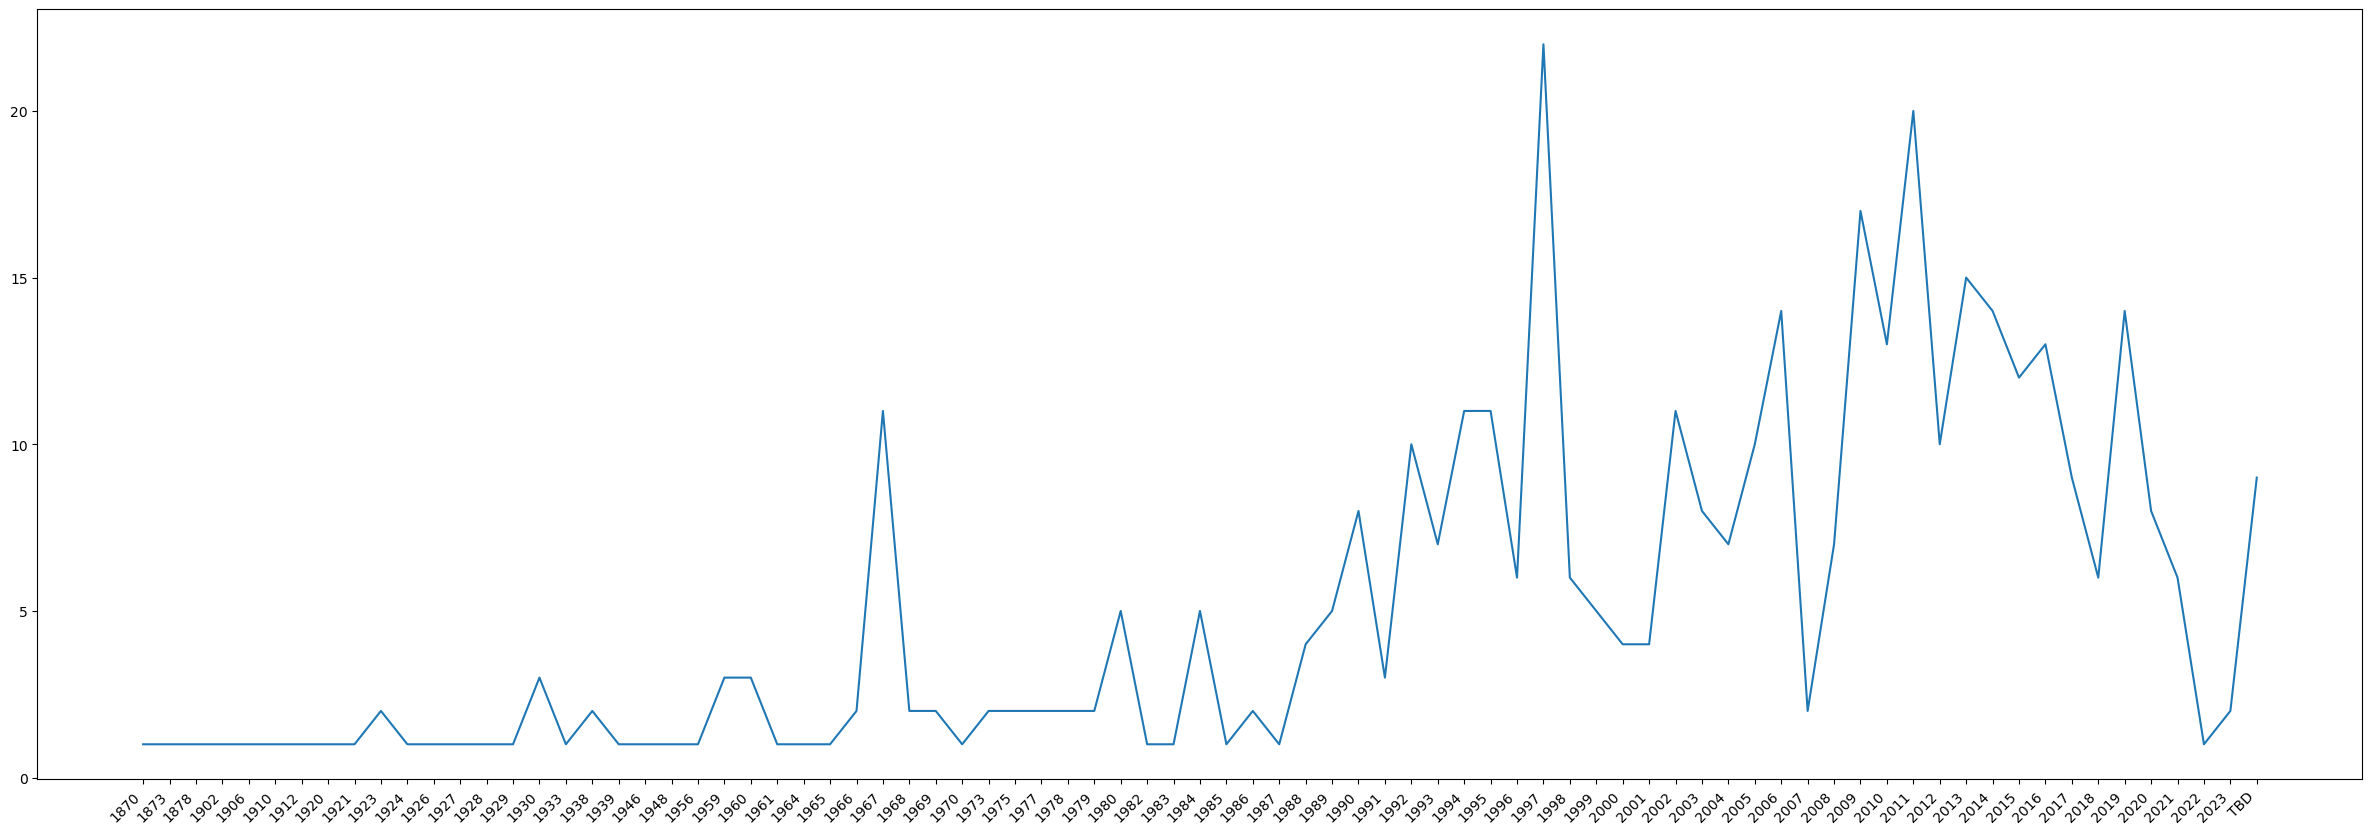

In [5]:
# visualize to determine filter
fig, ax = plt.subplots(figsize=(30, 10))
ax.plot(art_per_year)
plt.xticks(rotation=45, ha='right')
fig.show() 

It appears that there has been a sharp increase in public art displays since 1990s -- to ease the process of visualizing yearly trends, I will limit my focus to public art displays installed since 1990.

In [6]:
# first convert installation year column from string to int in a new column
# I'm doing this in a new column to keep art pieces listed as "TBD"
public_art['Installation_Year_Int'] = pd.to_numeric(public_art['Installation_Year'], errors='coerce', downcast="integer").dropna().astype(np.int64)

# limit to public art displays since 1990
public_art_included = public_art[(public_art['Installation_Year_Int'] >= 1990) | (public_art['Installation_Year'].str.upper() == 'TBD')].copy()

In [7]:
# determine how many sources there are to prepare plots
public_art_sources = public_art_included['Source'].unique()
public_art_sources

array(['Public Art & Monuments Collection - City-Owned',
       'Percent for Public Art - Private Developer Program',
       'Percent for Public Art Commissions Donated to the City'],
      dtype=object)

In [8]:
# aggregate installations per year
installations_per_year = public_art_included.groupby('Installation_Year').size()

# aggregate installations per year per source
city_owned = public_art_included[public_art_included['Source'] == public_art_sources[0]].groupby('Installation_Year').size()
private_dev = public_art_included[public_art_included['Source'] == public_art_sources[1]].groupby('Installation_Year').size()
private_donation = public_art_included[public_art_included['Source'] == public_art_sources[2]].groupby('Installation_Year').size()

In [9]:
# not all sources have installations in all years, need to add values to each subgroup
all_years = list(range(1990, 2024))

# Function to fill missing years in each aggregated dataframe
def fill_missing_years(dataframe, year_range):
    for year in year_range: # loop through each included year
        str_year = str(year) # convert to string, thanks to TBD ones
        if str_year not in dataframe.index:
            dataframe.loc[str_year] = 0 # if year is not included, add the year and 0 for installations
    return dataframe.sort_index()

In [10]:
# make sure each source has values for each included year
city_owned = fill_missing_years(city_owned, all_years)
private_dev = fill_missing_years(private_dev, all_years)
private_donation = fill_missing_years(private_donation, all_years)

In [11]:
# set theme, font and palette for plotting
sns.set_theme(style="white", font='Verdana')
palette = sns.color_palette("Set2")
palette

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961),
 (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

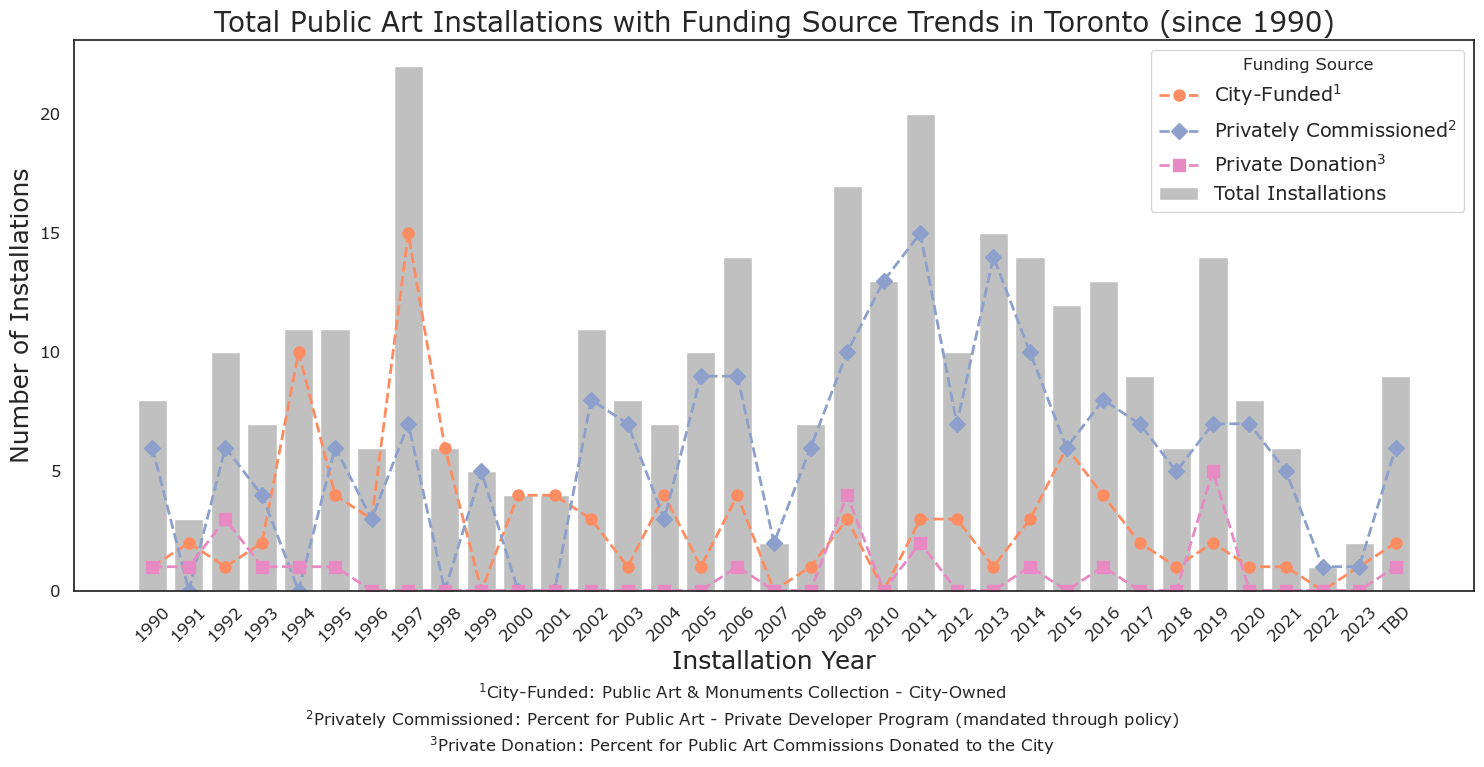

In [43]:
# start plot
fig, ax = plt.subplots(figsize=(15, 7))

# bar plot for total installations per year
ax.bar(installations_per_year.index, installations_per_year.values, color="silver", label='Total Installations')

# plot line for each source
ax.plot(city_owned.index, city_owned.values, label='City-Funded$^{1}$', color=palette[1], linewidth=2, linestyle="--", marker = "o", markersize = 8)
ax.plot(private_dev.index, private_dev.values, label='Privately Commissioned$^{2}$', color=palette[2], linewidth=2, linestyle="--", marker = "D", markersize = 8)
ax.plot(private_donation.index, private_donation.values, label='Private Donation$^{3}$', color=palette[3], linewidth=2, linestyle="--", marker = "s", markersize = 8)

# customize titles and labels
ax.set_title("Total Public Art Installations with Funding Source Trends in Toronto (since 1990)", fontsize=20)
ax.set_xlabel("Installation Year", fontsize=18)
ax.set_ylabel("Number of Installations", fontsize=18)
ax.legend(title="Funding Source", loc='upper right', fontsize=14)

# adding a caption to provide the longer names for the sources from the database
plt.figtext(0.5, -0.08, "$^{1}$City-Funded: Public Art & Monuments Collection - City-Owned\n$^{2}$Privately Commissioned: Percent for Public Art - Private Developer Program (mandated through policy)\n$^{3}$Private Donation: Percent for Public Art Commissions Donated to the City",
            wrap=True, horizontalalignment='center', fontsize=12)

# customize ticks
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()